This the HAM10000 ("Human Against Machine with 10000 training images") dataset. It consists of 10015 dermatoscopic images which are released as a training set for academic machine learning purposes and are publiclyavailable through the ISIC archive. This benchmark dataset can be used for machine learning and for comparisons with human experts.

It has 7 different classes of skin cancer which are listed below :
1. Melanocytic nevi
2. Melanoma
3. Benign keratosis-like lesions
4. Basal cell carcinoma
5. Actinic keratoses
6. Vascular lesions
7. Dermatofibroma

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Path to dataset files: /home/anita/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(123)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import itertools

import keras
from keras.utils.np_utils import to_categorical # used for converting labels to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras import backend as K
import itertools
from keras.utils.np_utils import to_categorical # convert to one-hot-encoding

from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split


from skimage.color import rgb2gray
from skimage.transform import resize
from FDApy.representation.functional_data import DenseFunctionalData, DenseArgvals, DenseValues
from FDApy.preprocessing import UFPCA
from FDApy.visualization import plot

2025-03-18 18:51:27.805090: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-18 18:51:28.095286: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-18 18:51:28.226789: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-18 18:51:28.902050: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

In [3]:
ls /home/anita/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2

ham10000_images_part_1/  HAM10000_images_part_2/  hmnist_28_28_RGB.csv
HAM10000_images_part_1/  HAM10000_metadata.csv    hmnist_8_8_L.csv
ham10000_images_part_2/  hmnist_28_28_L.csv       hmnist_8_8_RGB.csv


## Preprocessing
- Importing Essential Libraries
- Making Dictionary of images and labels
- Reading and Processing Data
- Data Cleaning
- Exploratory data analysis (EDA)
- Loading & Resizing of images
- Train Test Split

In [4]:
base_skin_dir = os.path.join('/home/anita/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2')

# Merging images from both folders HAM10000_images_part1.zip and HAM10000_images_part2.zip into one dictionary

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

# This dictionary is useful for displaying more human-friendly labels later on

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}


In [5]:
skin_df = pd.read_csv(os.path.join(base_skin_dir, 'HAM10000_metadata.csv'))

# Creating New Columns for better readability

skin_df['path'] = skin_df['image_id'].map(imageid_path_dict.get)
skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get) 
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes

skin_df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
9725,HAM_0004376,ISIC_0024843,akiec,histo,70.0,female,face,/home/anita/.cache/kagglehub/datasets/kmader/s...,Actinic keratoses,0
6059,HAM_0003024,ISIC_0024768,nv,follow_up,35.0,female,trunk,/home/anita/.cache/kagglehub/datasets/kmader/s...,Melanocytic nevi,4
4540,HAM_0001659,ISIC_0026564,nv,follow_up,35.0,male,lower extremity,/home/anita/.cache/kagglehub/datasets/kmader/s...,Melanocytic nevi,4
3817,HAM_0004625,ISIC_0029346,nv,follow_up,40.0,male,upper extremity,/home/anita/.cache/kagglehub/datasets/kmader/s...,Melanocytic nevi,4
7914,HAM_0000443,ISIC_0034271,nv,histo,35.0,female,back,/home/anita/.cache/kagglehub/datasets/kmader/s...,Melanocytic nevi,4


In [6]:
skin_df['age'].fillna((skin_df['age'].mean()), inplace=True)

/tmp/ipykernel_11499/3479505362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  skin_df['age'].fillna((skin_df['age'].mean()), inplace=True)


In [7]:
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lesion_id      10015 non-null  object 
 1   image_id       10015 non-null  object 
 2   dx             10015 non-null  object 
 3   dx_type        10015 non-null  object 
 4   age            10015 non-null  float64
 5   sex            10015 non-null  object 
 6   localization   10015 non-null  object 
 7   path           10015 non-null  object 
 8   cell_type      10015 non-null  object 
 9   cell_type_idx  10015 non-null  int8   
dtypes: float64(1), int8(1), object(8)
memory usage: 714.1+ KB


cell_type
Melanocytic nevi                  6705
Melanoma                          1113
Benign keratosis-like lesions     1099
Basal cell carcinoma               514
Actinic keratoses                  327
Vascular lesions                   142
Dermatofibroma                     115
Name: count, dtype: int64

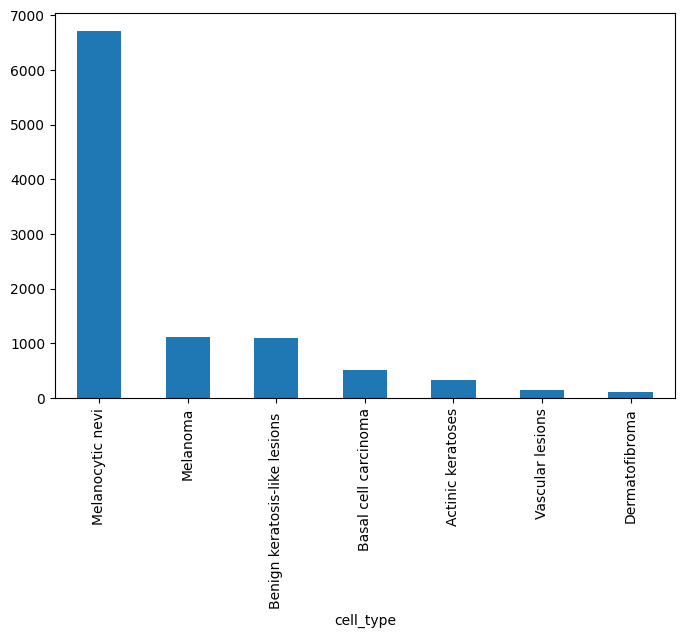

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize= (8, 5))
skin_df['cell_type'].value_counts().plot(kind='bar', ax=ax1)
skin_df['cell_type'].value_counts()

In [9]:
skin_df_balanced = skin_df.copy()
excess_classes = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
for cl in excess_classes:
    tmp_df1 = skin_df_balanced[skin_df_balanced['dx'] == cl]
    tmp_df2 = skin_df_balanced[skin_df_balanced['dx'] != cl]
    tmp_df1 = tmp_df1.sample(n=100, random_state=42)
    skin_df_balanced = pd.concat([tmp_df1, tmp_df2], ignore_index=True)
skin_df_balanced['cell_type'].value_counts()

cell_type
Actinic keratoses                 100
Basal cell carcinoma              100
Vascular lesions                  100
Melanoma                          100
Dermatofibroma                    100
Melanocytic nevi                  100
Benign keratosis-like lesions     100
Name: count, dtype: int64

In [10]:
skin_df_balanced['image'] = skin_df_balanced['path'].map(lambda x: 
                            np.array(rgb2gray(np.asarray(Image.open(x).resize((512,512))))))
skin_df_balanced['image'] = skin_df_balanced['image'].tolist()

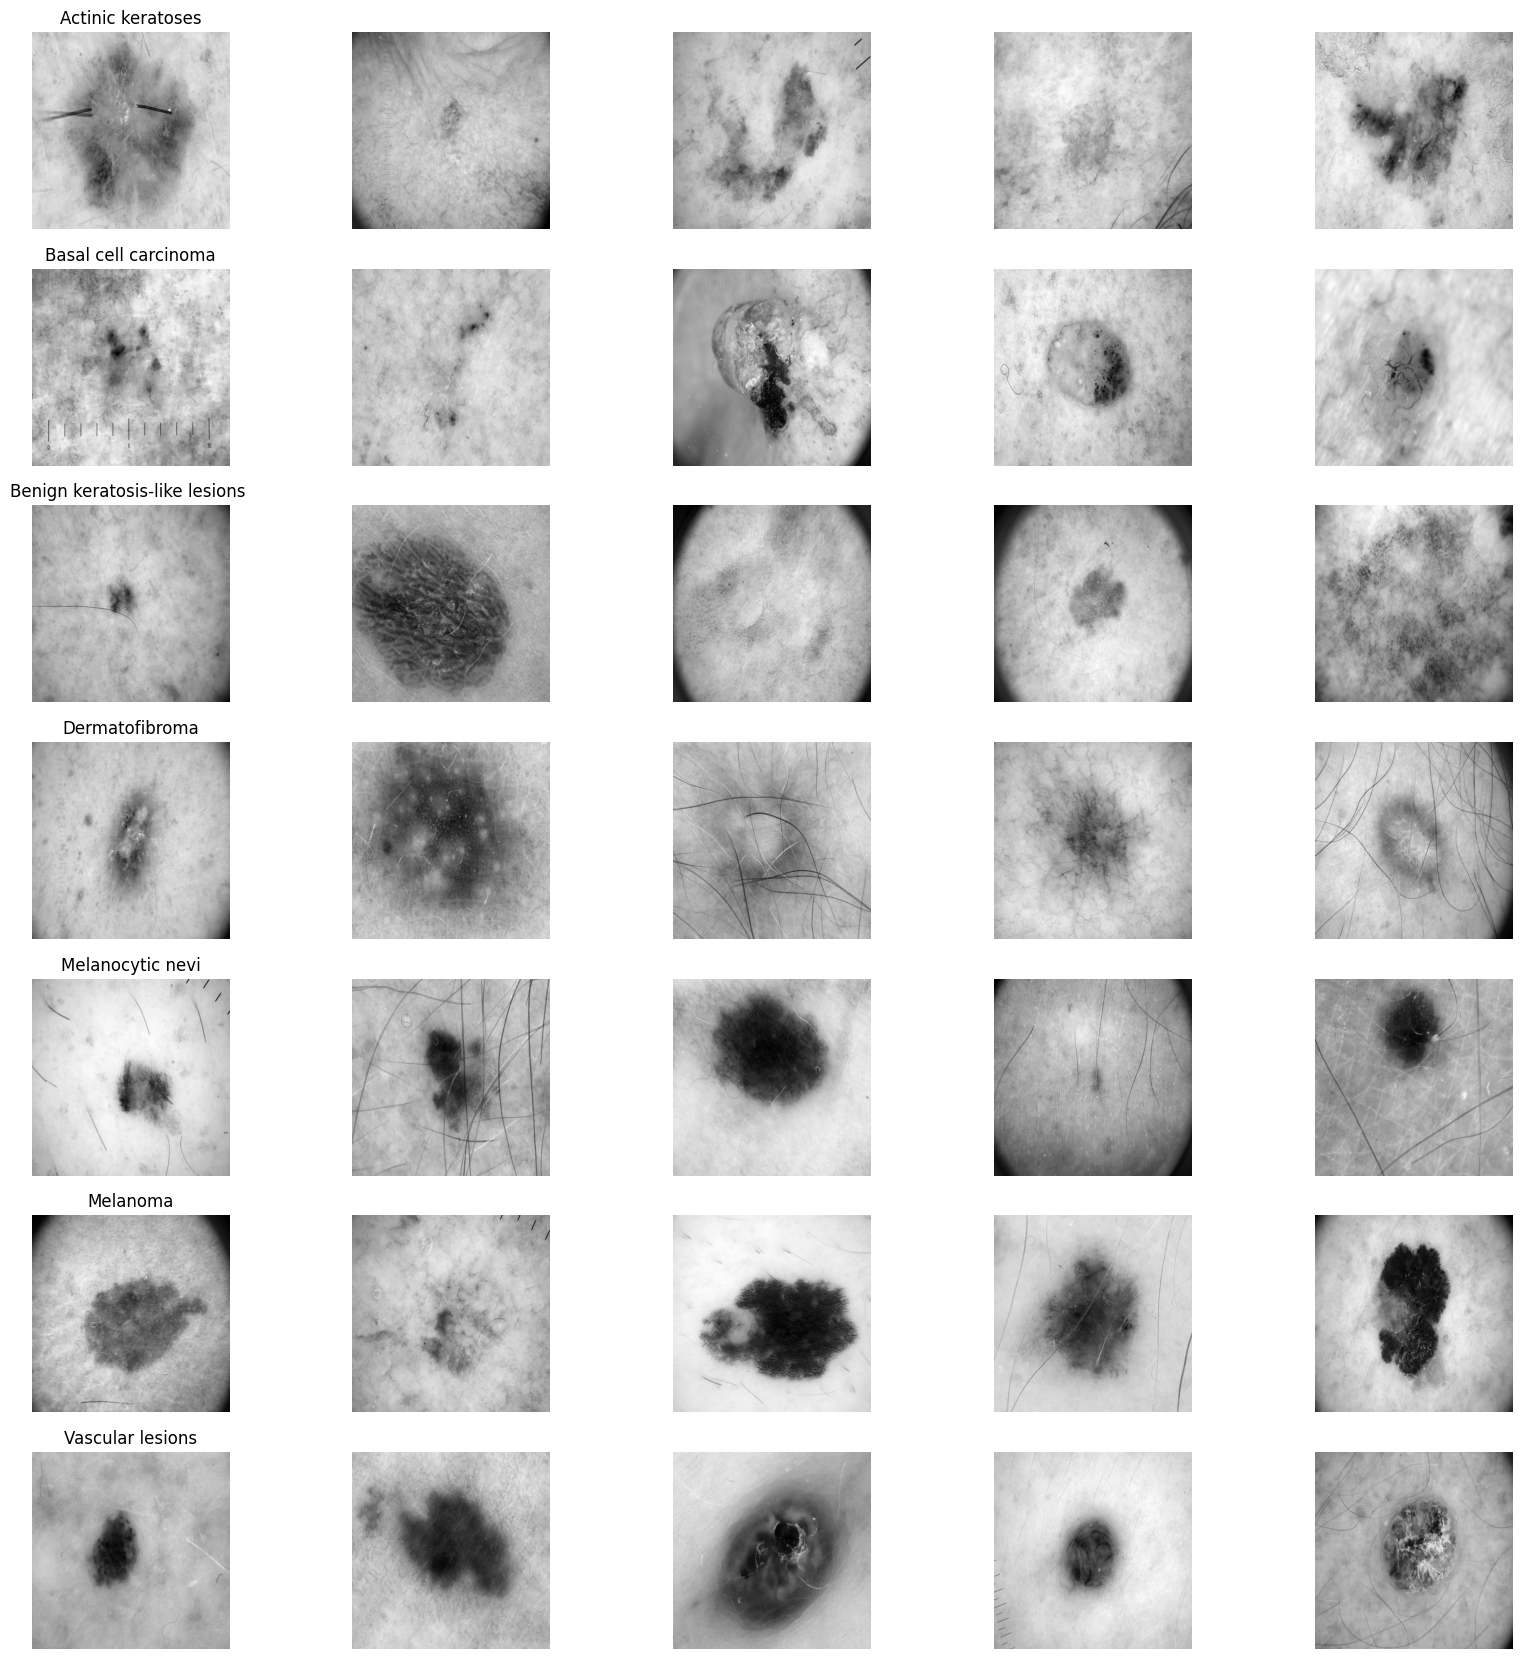

In [11]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, skin_df_balanced.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'], cmap='gray')
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

In [12]:
features=skin_df.drop(columns=['cell_type_idx'],axis=1)
target=skin_df['cell_type_idx']

In [13]:
images = np.array(skin_df_balanced['image'].to_list())
skin_df_balanced['image'].tolist()
print("Images array shape:", images.shape)

Images array shape: (700, 512, 512)


In [21]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(skin_df_balanced['dx'])
skin_df_balanced['dx']=le.transform(skin_df_balanced['dx'])
le.fit(skin_df_balanced['dx'])
skin_df_balanced['dx']=le.transform(skin_df_balanced['dx'])
y = skin_df_balanced['dx']
print(skin_df_balanced['dx'].unique())

[0 1 6 4 3 5 2]


In [22]:
def preprocess_images(images, new_size):
    resized_images = np.array([resize(img, (new_size, new_size), anti_aliasing=True) for img in images])
    flattened = resized_images.reshape(resized_images.shape[0], -1)
    return flattened

X = preprocess_images(images, 512)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=labels
)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (560, 262144)
Test set shape: (140, 262144)


In [17]:
def create_functional_data(X):
    num_points = X.shape[1]
    argvals = DenseArgvals({'input_dim_0': np.linspace(0, 1, num_points)})
    return DenseFunctionalData(argvals, DenseValues(X))

fdata_train  = create_functional_data(X_train)
fdata_test = create_functional_data(X_test)

In [34]:
def create_dense_functional_data(X):
    """
    Given X of shape (n_obs, m1, m2), create a DenseFunctionalData object.
    """
    n_obs, m1, m2 = X.shape
    # Create a grid for each dimension.
    # Ensure that the keys are sorted (here by name) so that the dimensions match.
    argvals_dict = dict(sorted({'input_dim_0': np.linspace(0, 1, m1),
                                  'input_dim_1': np.linspace(0, 1, m2)}.items()))
    argvals = DenseArgvals(argvals_dict)
    values = DenseValues(X)
    # This will check that the product of lengths of argvals equals the product of grid dimensions in X.
    dfd = DenseFunctionalData(argvals, values)
    return dfd

## FCPTPA Usage


Sparse Penalty Matrices:
Instead of constructing a dense penalty matrix (which in a tensor product would lead to a huge matrix of size (512×512, 512×512)), we create sparse matrices using SciPy’s sp.diags. This keeps the memory footprint low.


FCPTPA is used for 2D data (images) to extract a low‑rank representation without forming huge covariance matrices. The resulting FPCA scores (here with shape (1000, 50)) can be used as features for classification.







In [49]:
from FDApy.representation import MultivariateFunctionalData
from FDApy.preprocessing import FCPTPA
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score


dfd = create_dense_functional_data(images)
dfd

Functional data object with 700 observations on a 2-dimensional support.

In [56]:
import scipy.sparse as sp

def diff_penalty_sparse(n):
    """
    Create a first-order difference penalty matrix as a sparse matrix of shape (n, n)
    using a difference operator.
    """
    data = np.array([np.ones(n), -np.ones(n)])
    offsets = [0, 1]
    D = sp.diags(data, offsets, shape=(n-1, n), format='csr')
    P = D.T @ D
    return P

P_v = diff_penalty_sparse(images.shape[1])  # For rows
P_w = diff_penalty_sparse(images.shape[2])  # For columns

penalty_matrices = {'v': P_v.toarray(), 'w': P_w.toarray()}
# Set a range for the smoothing parameters 
alpha_range = {'v': (1e-2, 1e2), 'w': (1e-2, 1e2)}

fcptpa = FCPTPA(n_components=50, normalize=True)


In [57]:
penalty_matrices

{'v': array([[ 1., -1.,  0., ...,  0.,  0.,  0.],
        [-1.,  2., -1., ...,  0.,  0.,  0.],
        [ 0., -1.,  2., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  2., -1.,  0.],
        [ 0.,  0.,  0., ..., -1.,  2., -1.],
        [ 0.,  0.,  0., ...,  0., -1.,  1.]]),
 'w': array([[ 1., -1.,  0., ...,  0.,  0.,  0.],
        [-1.,  2., -1., ...,  0.,  0.,  0.],
        [ 0., -1.,  2., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  2., -1.,  0.],
        [ 0.,  0.,  0., ..., -1.,  2., -1.],
        [ 0.,  0.,  0., ...,  0., -1.,  1.]])}


Components = 0

Absolute error:
u: 2.6407740602410443e-05, v: 0.0012531922822683582, w: 4.648953362533492e-05, alpha_v: 0.010004507614747166, alpha_w: 0.010004507614747166.

Components = 1

Absolute error:
u: 2.0303946216896682e-07, v: 10.60702043427936, w: 3.0412583383242087e-05, alpha_v: 15.97272393932942, alpha_w: 99.99999056200816.

Components = 2

Absolute error:
u: 2.2467160393790124e-06, v: 0.6653034639046242, w: 4.9274900541711564e-05, alpha_v: 11.137850886827975, alpha_w: 99.99999438766281.

Components = 3

Absolute error:
u: 0.000664546137479579, v: 159.95304560588167, w: 0.012854106571650994, alpha_v: 6.144664008831715, alpha_w: 99.99999259790198.

Components = 4

Absolute error:
u: 0.0029799908307072418, v: 0.013263300017029958, w: 5.4626919865789234e-05, alpha_v: 0.010004507614747166, alpha_w: 0.09108721398548522.

Components = 5

Absolute error:
u: 0.004334408867572749, v: 207.7664318439483, w: 0.09186352187798916, alpha_v: 7.203059681139932, alpha_w: 84.36963218255626.


Shape of FCPTPA scores: (700, 50)


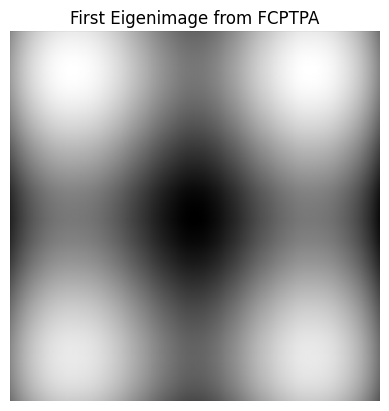

Test Accuracy: 0.32142857142857145


In [58]:
fcptpa.fit(
    dfd,
    penalty_matrices=penalty_matrices,
    alpha_range=alpha_range,
    tolerance=1e-4,
    max_iteration=15,
    adapt_tolerance=True,
    verbose=True
)

# Transform the data into FPCA scores.
# The scores will be a NumPy array of shape (1000, 50)
scores = fcptpa.transform(dfd, method='NumInt')
print("Shape of FCPTPA scores:", scores.shape)

first_eigenimage = fcptpa.eigenfunctions.values[0].reshape(images.shape[1], images.shape[2])
plt.imshow(first_eigenimage, cmap='gray')
plt.title("First Eigenimage from FCPTPA")
plt.axis('off')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    scores, y, test_size=0.2, random_state=42, stratify=y
)

clf = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

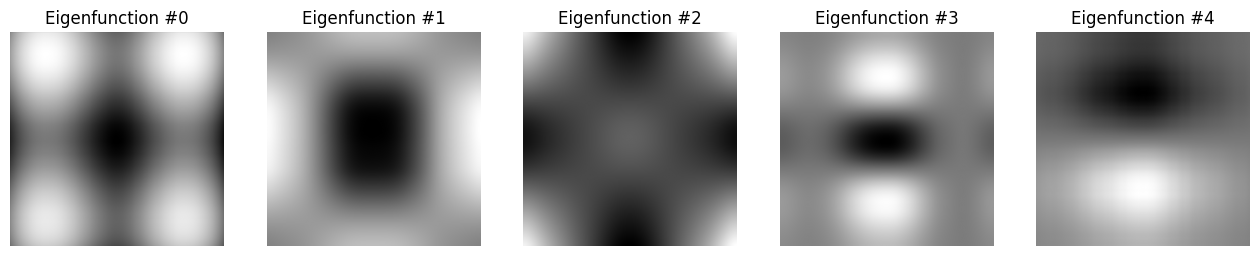

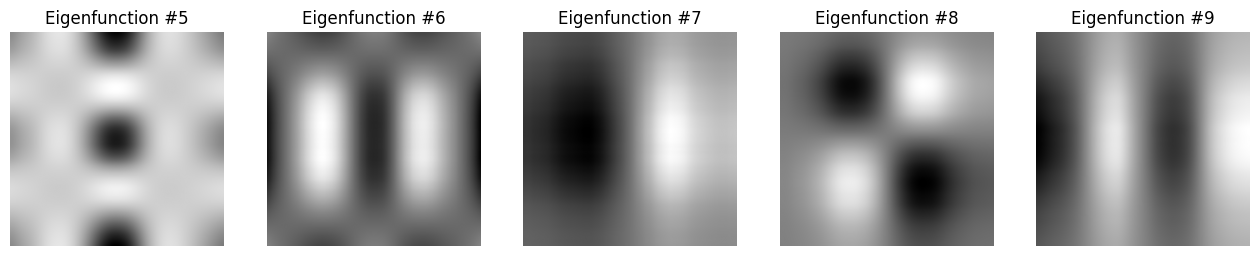

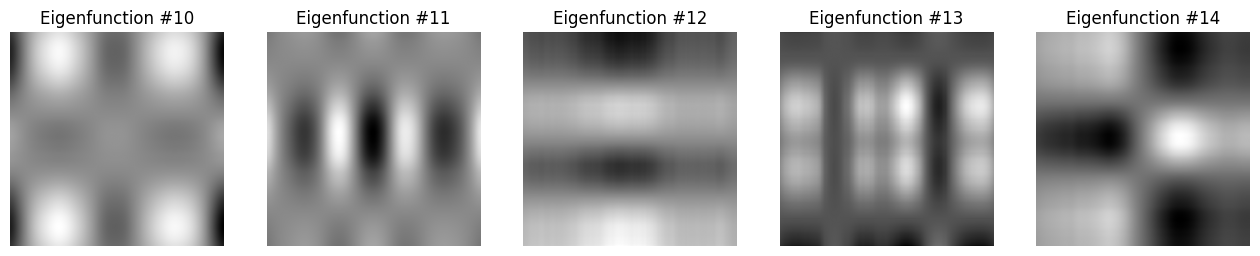

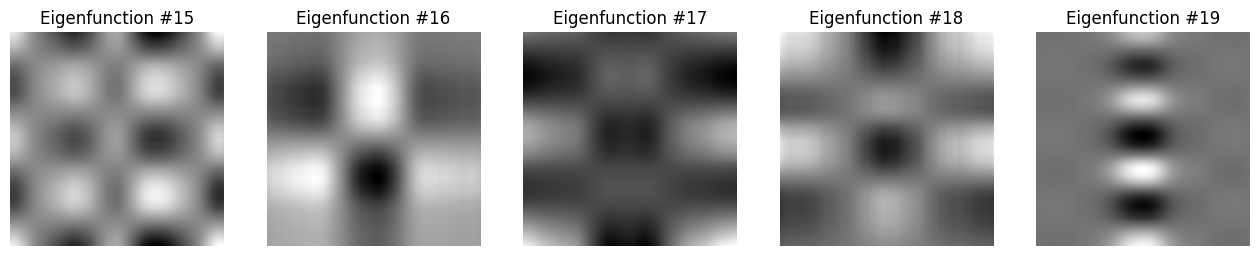

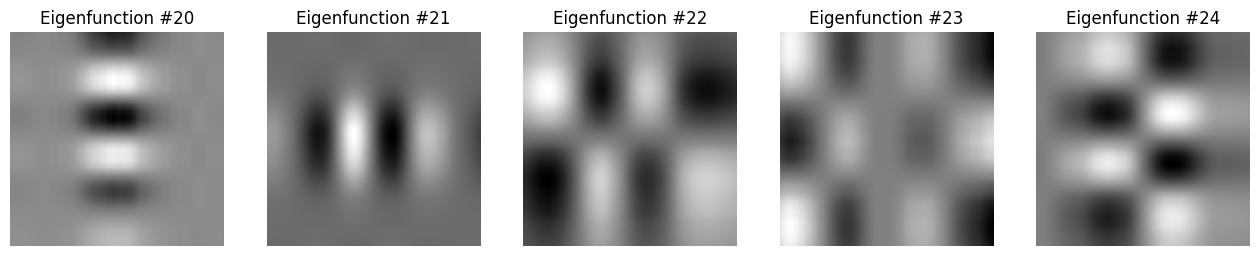

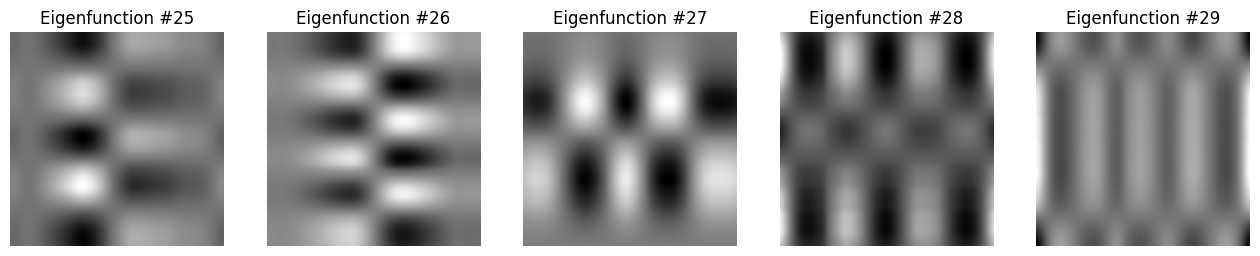

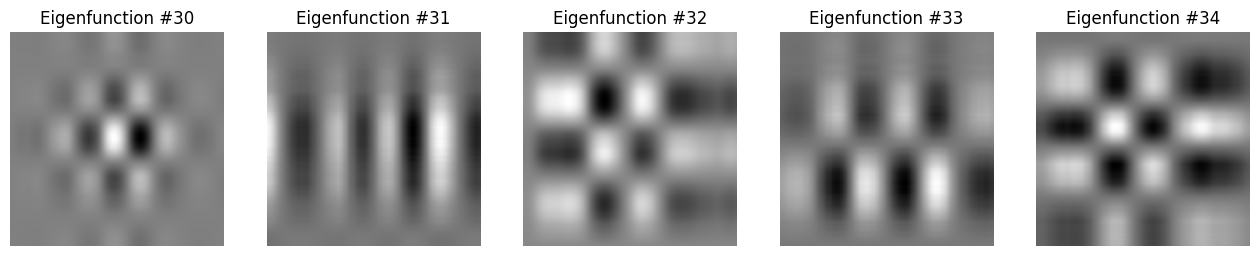

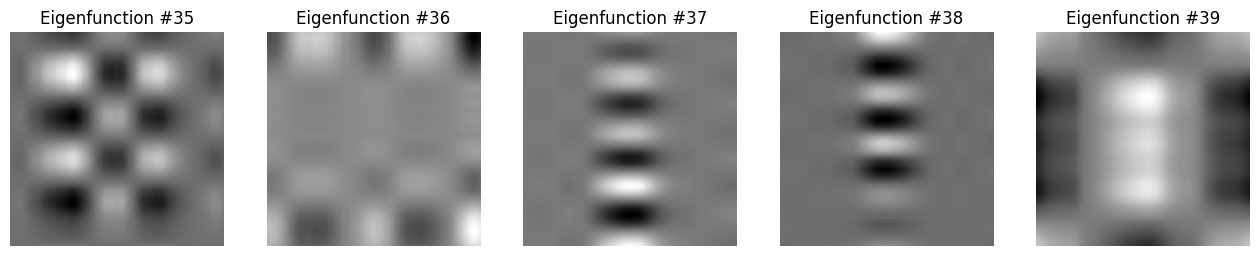

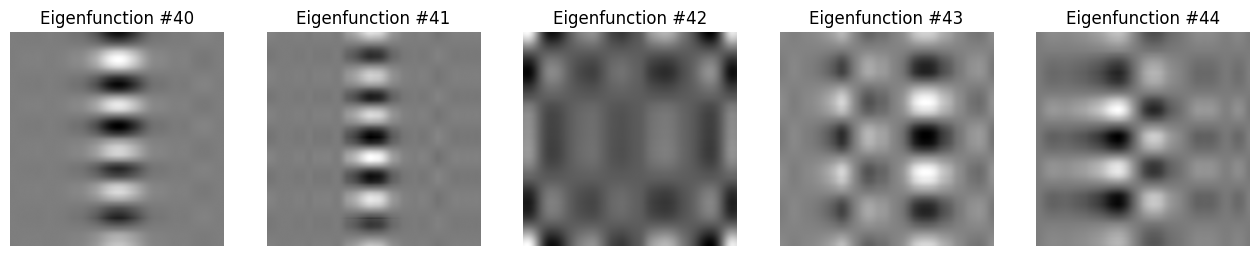

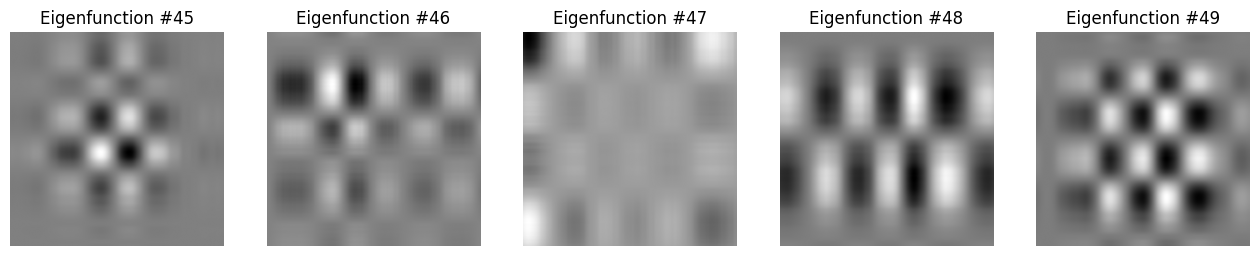

In [62]:
n_axes = 5
for i in range(0, 50, n_axes):
    fig, axes = plt.subplots(1, n_axes, figsize=(16, 3))
    for j in range(n_axes):
        axes[j].imshow(fcptpa.eigenfunctions.values[i+j].reshape(512, 512), cmap='gray')
        axes[j].set_title("Eigenfunction #" + str(i+j))
        axes[j].axis("off") 
        

The FCPTPA eigenfunctions exhibit more linear or banded patterns, suggesting sensitivity to directional features (e.g., horizontal/vertical edges, illumination artifacts)

In [66]:
fcptpa_list = []
acc_list = []
acc_list_x = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200]


for n_components in acc_list_x:
    fcptpa = FCPTPA(n_components=n_components, normalize=True)
    fcptpa.fit(
        dfd,
        penalty_matrices=penalty_matrices,
        alpha_range=alpha_range,
        tolerance=1e-4,
        max_iteration=15,
        adapt_tolerance=True,
        verbose=False
    )
    scores = fcptpa.transform(dfd, method='NumInt')
    X_train, X_test, y_train, y_test = train_test_split(
        scores, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_seed=42
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(n_components, "Test Accuracy:", acc)
    acc_list.append(acc)
    fcptpa_list.append(fcptpa)

5 Test Accuracy: 0.2785714285714286
10 Test Accuracy: 0.2642857142857143
15 Test Accuracy: 0.32142857142857145
20 Test Accuracy: 0.2857142857142857
30 Test Accuracy: 0.24285714285714285
50 Test Accuracy: 0.3142857142857143
75 Test Accuracy: 0.37142857142857144
100 Test Accuracy: 0.3142857142857143
150 Test Accuracy: 0.37142857142857144
200 Test Accuracy: 0.2857142857142857


/tmp/ipykernel_11499/17684773.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


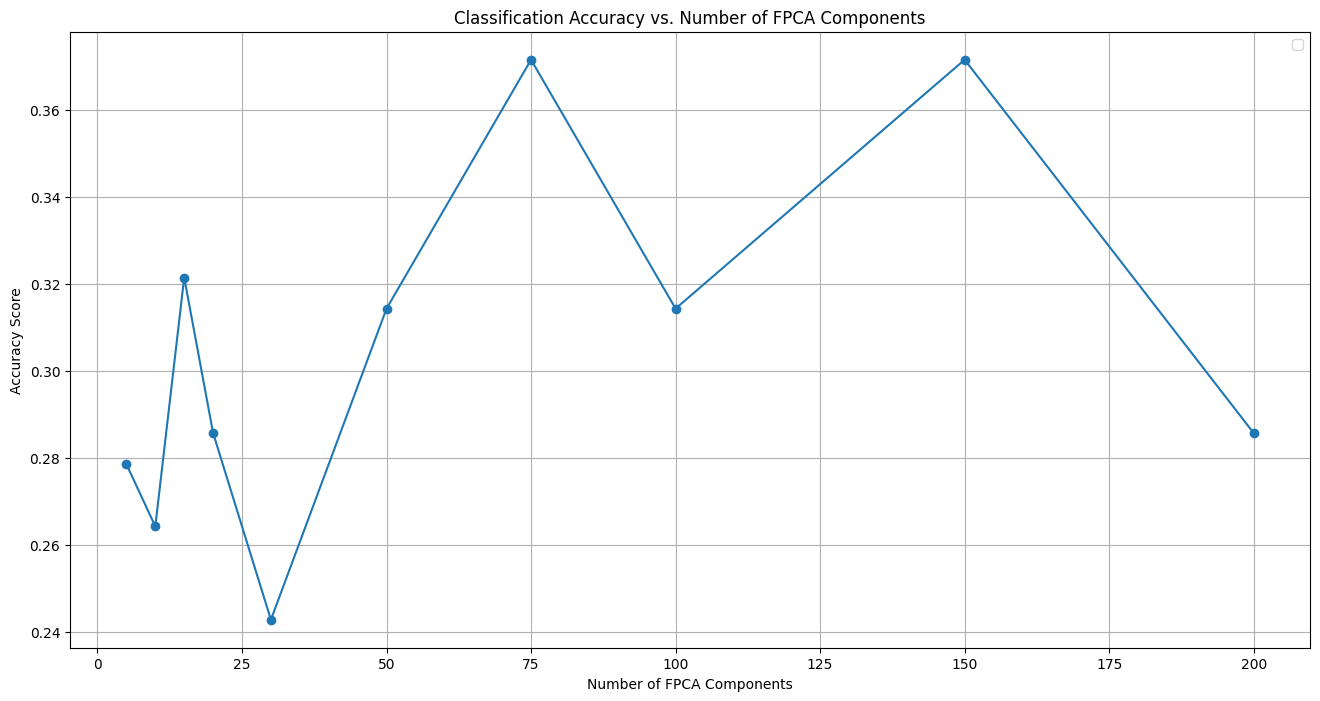

In [68]:
plt.figure(figsize=(16, 8))
plt.plot(acc_list_x, acc_list, 'o-')
plt.grid(True)
plt.xlabel('Number of FPCA Components')
plt.ylabel('Accuracy Score')
plt.title("Classification Accuracy vs. Number of FPCA Components")
plt.legend()
plt.show()


In [ ]:
acc_list_fcptpa = [0.2785714285714286, 0.2642857142857143, 0.32142857142857145,  0.2857142857142857,
                    0.24285714285714285,  0.3142857142857143, 0.37142857142857144, 0.3142857142857143,
                    0.37142857142857144, 0.2857142857142857]

5 Test Accuracy: 0.2785714285714286 

10 Test Accuracy: 0.2642857142857143

15 Test Accuracy: 0.32142857142857145

20 Test Accuracy: 0.2857142857142857

30 Test Accuracy: 0.24285714285714285

50 Test Accuracy: 0.3142857142857143

75 Test Accuracy: 0.37142857142857144

100 Test Accuracy: 0.3142857142857143

150 Test Accuracy: 0.37142857142857144

200 Test Accuracy: 0.2857142857142857


In [81]:
def preprocess_images(images, new_size):
    # Resize each image to (new_size, new_size)
    # Here images is assumed to be a list/array of images.
    resized_images = np.array([resize(img, (new_size, new_size), anti_aliasing=True) for img in images])
    return resized_images

def create_functional_data(X, sampling_factor=8):
    """
    Given X of shape (n, h, w) create a DenseFunctionalData object representing 
    a one-dimensional function for each image.
    
    Instead of using all h*w points, this function downsamples the grid by the
    provided sampling_factor along both dimensions. For example, with h=w=512 and 
    sampling_factor=16, the new grid will have shape (32, 32) i.e. 1024 points.
    """
    n, h, w = X.shape
    new_h, new_w = h // sampling_factor, w // sampling_factor
    # Downsample each image by taking every sampling_factor-th pixel in both directions.
    X_down = X[:, ::sampling_factor, ::sampling_factor]
    num_points = new_h * new_w
    # Create a 1D grid for the functional representation (length = new_h * new_w)
    argvals = DenseArgvals({'input_dim_0': np.linspace(0, 1, num_points)})
    # Flatten each downsampled image to a vector of length new_h*new_w.
    X_flat = X_down.reshape(n, -1)
    return DenseFunctionalData(argvals, DenseValues(X_flat))


images_new  = preprocess_images(images, 512)
dfd = create_functional_data(images_new)


In [83]:
fpca = UFPCA(n_components=50)
fpca.fit(dfd)

X_train, X_test, y_train, y_test = train_test_split(
    scores, y, test_size=0.2, random_state=42, stratify=y
)

clf = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.2714285714285714


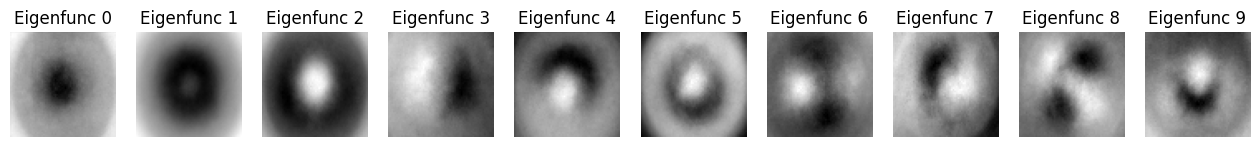

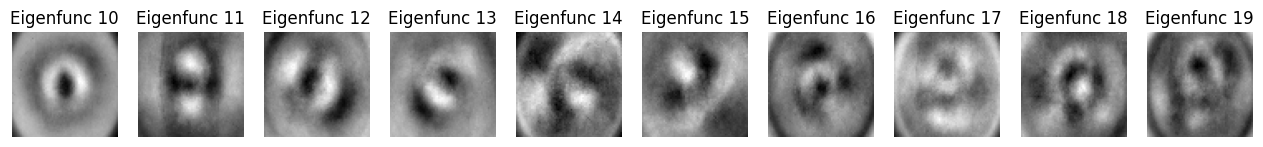

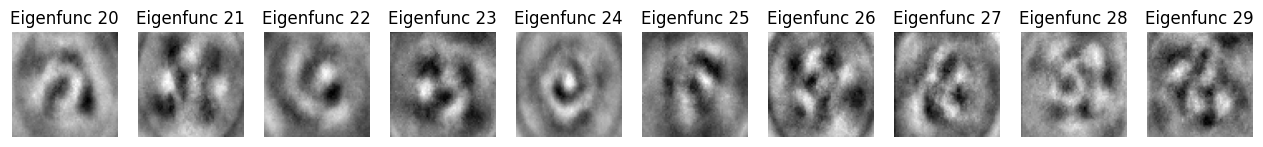

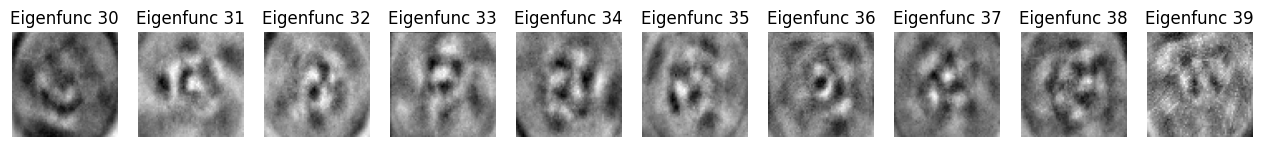

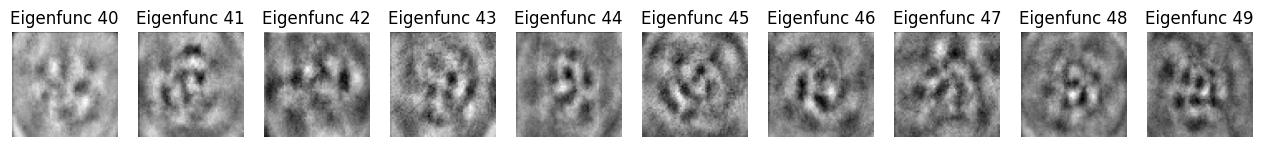

In [85]:
n_axes = 10
for i in range(0, 50, n_axes):
    fig, axes = plt.subplots(1, n_axes, figsize=(16, 3))
    for j in range(n_axes):
        axes[j].imshow(fpca.eigenfunctions[i+j].to_long().values[:, 2].reshape(64, 64), cmap='gray')
        axes[j].set_title("Eigenfunc " + str(i+j))
        axes[j].axis("off") 
        

The FPCA eigenfunctions appear to capture more circular or radially symmetric intensity patterns, reflecting global variations (e.g., central lesion vs. boundary transitions).

In dermatoscopic images, radial patterns may correspond to overall lesion shape, color gradients, or “halo” effects, while linear/banded patterns could capture edges, hair artifacts, or lighting stripes.

In [86]:
fpca_list = []
acc_list = []
acc_list_x = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200]


for n_components in acc_list_x:
    fpca = UFPCA(n_components=n_components)
    fpca.fit(dfd)
    scores = fpca.transform(dfd)
    X_train, X_test, y_train, y_test = train_test_split(
        scores, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_seed=42
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(n_components, "Test Accuracy:", acc)
    acc_list.append(acc)
    fpca_list.append(fcptpa)

5 Test Accuracy: 0.2714285714285714
10 Test Accuracy: 0.38571428571428573
15 Test Accuracy: 0.3
20 Test Accuracy: 0.30714285714285716
30 Test Accuracy: 0.37857142857142856
50 Test Accuracy: 0.37142857142857144
75 Test Accuracy: 0.2714285714285714
100 Test Accuracy: 0.2714285714285714
150 Test Accuracy: 0.37857142857142856
200 Test Accuracy: 0.29285714285714287


In [88]:
acc_list_fcptpa = [0.2785714285714286, 0.2642857142857143, 0.32142857142857145,  0.2857142857142857,
                    0.24285714285714285,  0.3142857142857143, 0.37142857142857144, 0.3142857142857143,
                    0.37142857142857144, 0.2857142857142857]

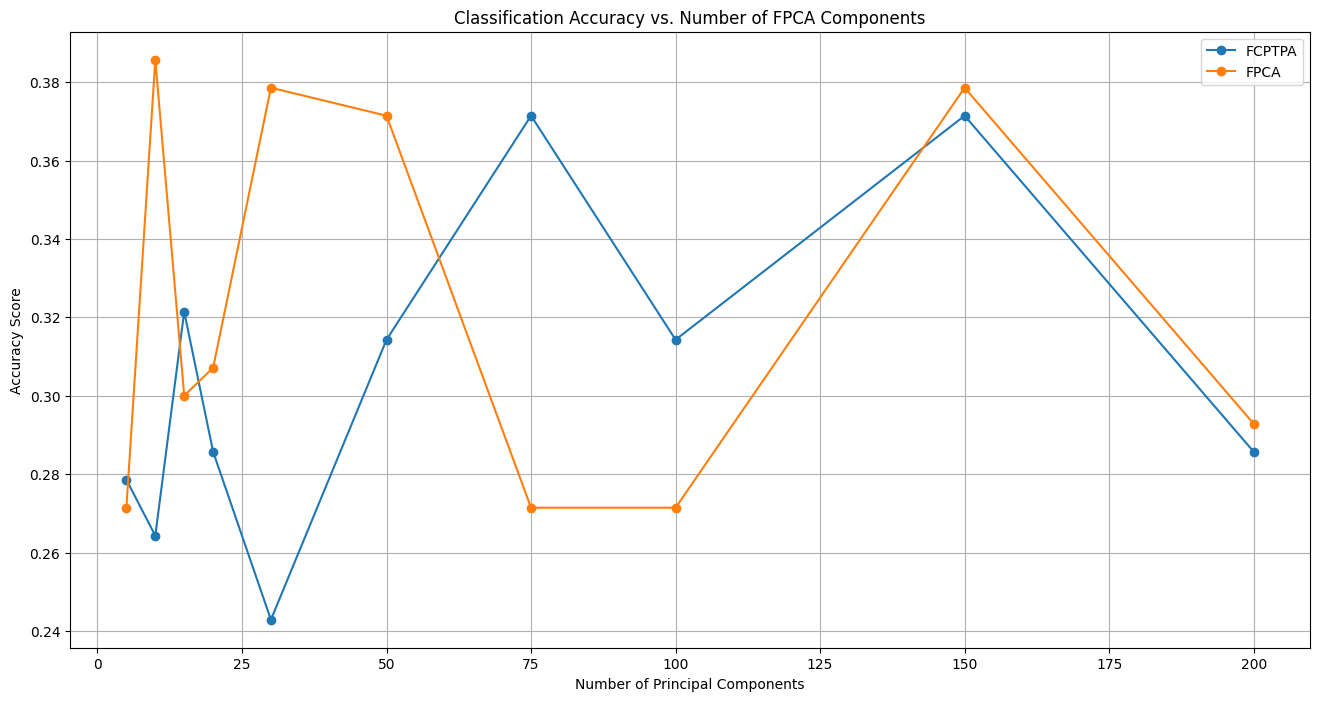

In [89]:
plt.figure(figsize=(16, 8))
plt.plot(acc_list_x, acc_list_fcptpa, 'o-', label = 'FCPTPA')
plt.plot(acc_list_x, acc_list, 'o-', label = 'FPCA')
plt.grid(True)
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy Score')
plt.title("Classification Accuracy vs. Number of FPCA Components")
plt.legend()
plt.show()


### Accuracy Chart Observations

- Both methods show fluctuating accuracy as the number of principal components increases; there is no smooth, monotonic improvement.
- In some ranges (e.g., around 25–50 components), FCPTPA outperforms FPCA, whereas in other ranges (e.g., near 150 components), FPCA has the advantage.
- The large variability implies that each method extracts different modes of variation; the “best” component count depends on how those modes align with classification goals.

# Conclusion
1. Choosing between FPCA and FCPTPA—and tuning the component count—requires domain knowledge (e.g., the importance of global vs. local features) and systematic experimentation:
    - FPCA may emphasize more global, radially oriented structures, potentially useful for overall lesion shape characterization.
    - FCPTPA might better capture directional or edge-based patterns, which can be crucial for certain lesion subtypes.
2. High accuracy spikes at certain component counts suggest there may be an optimal “sweet spot” where enough meaningful variation is captured without overfitting noise.
3. The variability in performance underscores the need for careful hyperparameter search; neither method is universally superior across all component counts.

